In [1]:
import pandas as pd
import numpy as np

import sys
import os

# Get the current working directory (where the notebook is running)
notebook_dir = os.getcwd()

# Go up one level to the parent directory
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

# Add parent directory to sys.path
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [13]:
df_correlations = pd.read_csv("preprocessed_data/corr_DICER1_preprocessed.csv", delimiter=";")
df_correlations

,gene_selected,gene_evaluated,corr,pvalue,rank,is_on_pathway
0,DICER1,DICER1,1,Inf,1,1
1,DICER1,XPO5,"0,503616844","52,45448018",2,1
2,DICER1,DROSHA,"0,33792351","22,30645548",3,1
3,DICER1,AGO2,"0,329596473","21,20102211",4,1
4,DICER1,ANKRD52,"0,298301131","17,34229262",5,1
...,...,...,...,...,...,...
495,DICER1,ZSCAN22,"0,107406007","2,650848984",496,0
496,DICER1,PCDHB16,"0,107365194","2,649156285",497,0
497,DICER1,ORMDL2,"-0,107302495","2,646556921",498,0
498,DICER1,HYOU1,"0,107170677","2,641096374",499,0


In [74]:
plot_df = pd.concat([df_correlations[["gene_evaluated", "corr", "is_on_pathway"]][:15], 
                    df_correlations[["gene_evaluated", "corr", "is_on_pathway"]][-15:]])

plot_df['corr'] = plot_df['corr'].str.replace(',', '.', regex=False)

# 2. Convert the column's data type from object (text) to float.
plot_df['corr'] = pd.to_numeric(plot_df['corr'])
plot_df["corr"]

plot_df

,gene_evaluated,corr,is_on_pathway
0,DICER1,1.000000,1
1,XPO5,0.503617,1
2,DROSHA,0.337924,1
3,AGO2,0.329596,1
4,ANKRD52,0.298301,1
5,DGCR8,0.281137,1
6,DOLK,0.243668,0
7,MNAT1,0.210100,0
8,MAP4K4,-0.208074,0
9,RBSN,0.207383,0


In [75]:
df_correlations[["gene_evaluated", "corr", "is_on_pathway"]][-15:]

,gene_evaluated,corr,is_on_pathway
485,VSIG1,"-0,109203042",0
486,ATRX,"0,1099485",0
487,TMPO,"-0,107852559",0
488,SGK1,"0,107839321",0
489,NR2F1,"0,107779043",0
490,RHAG,"0,10772311",0
491,STAT6,"-0,107700023",0
492,JAG1,"0,107616645",0
493,HIRIP3,"-0,107563224",0
494,NAT1,"-0,107482807",0


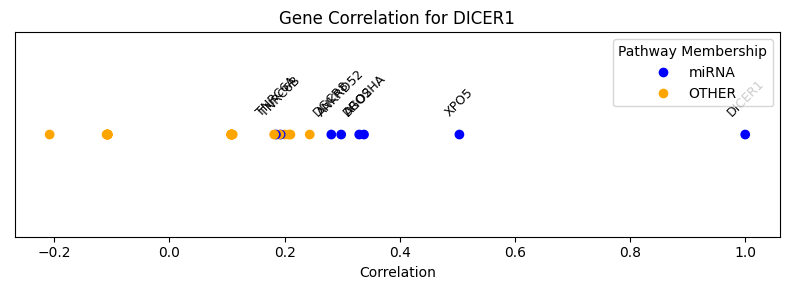

In [76]:
import matplotlib.pyplot as plt
import pandas as pd

# Create the scatter plot with spacing by correlation (x-axis)



plt.figure(figsize=(8, 3))
colors = plot_df['is_on_pathway'].map({1: 'blue', 0: 'orange'})

# Plot points
plt.scatter(plot_df['corr'], [0]*len(plot_df), c=colors)

# Add labels for each gene
for i, row in plot_df.iterrows():
    if row["is_on_pathway"] == 1:
        plt.text(row['corr'], 0.01, row['gene_evaluated'], rotation=45, ha='center', fontsize=9)

    else:
        plt.text(row['corr'], 0.01, " ", rotation=45, ha='center', fontsize=9)

# Formatting
plt.yticks([])
plt.xlabel('Correlation')
plt.title('Gene Correlation for DICER1')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='miRNA', markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='OTHER', markerfacecolor='orange', markersize=8)
], title='Pathway Membership')
plt.tight_layout()
plt.show()

